# Clasificador ECHO: crop + padding 20% + K fold cross validation

Este notebook entrena ResNet50 usando imágenes originales (`source_img_path`) y las detecciones de `detections_metadata.json`, pero reconstruyendo el dataset como crop del detector con padding de 20%.

Luego usa StratifiedKFold con 3 folds para validación interna y evalúa el mejor checkpoint sobre el test externo, aplicando nuevamente detector + crop con padding 20%.

## 1. Setup e imports

In [ ]:
!pip -q install scikit-learn tqdm matplotlib pandas openpyxl PytorchWildlife

import os
import re
import json
import zipfile
import random
import shutil
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.amp import autocast, GradScaler

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)

from PIL import Image, ImageOps, ImageFile
import openpyxl

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponible:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.4/953.4 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.6 MB/s eta 0:00:00

## 2. Configuración general

In [ ]:
USE_GOOGLE_DRIVE = True

# Rutas principales
DRIVE_METADATA_PATH = "/content/drive/MyDrive/ECHO/Metadata/detections_metadata.json"
DRIVE_SNAPSHOT_ROOT = "/content/drive/MyDrive/ECHO/snapshot_images"

WORK_DIR = Path("/content/saviia_species_training_crop_padding20_cv")
DATA_ROOT = WORK_DIR / "crop_padding20_images"
OUTPUT_DIR = WORK_DIR / "outputs_crop_padding20_cv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Crop con padding
CROP_PADDING_RATIO = 0.20
FORCE_REBUILD_PADDED_DATASET = True
SAVE_CROPS_AS_JPEG = True
JPEG_QUALITY = 95

# Entrenamiento
SEED = 42
IMG_SIZE = 224
N_SPLITS = 3
BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = True

# Como se entrena 3 veces, estos valores son más cortos que el entrenamiento original.
EPOCHS_HEAD = 2
EPOCHS_FINETUNE = 4

LR_HEAD = 3e-4
LR_FINETUNE = 3e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
USE_WEIGHTED_SAMPLER = False

# metrica para elegir mejor checkpoint de cada folder en el cross-validation
SELECTION_METRIC = "val_f1_macro"  # opciones: val_acc, val_f1_macro, val_f1_weighted

# Outputs
CROP_METADATA_PATH = OUTPUT_DIR / "crop_padding20_metadata.csv"
CV_SUMMARY_PATH = OUTPUT_DIR / "cv_summary.csv"
CV_HISTORY_PATH = OUTPUT_DIR / "cv_history_all_folds.csv"
CLASS_MAPPING_PATH = OUTPUT_DIR / "class_mapping_crop_padding20.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## 3. Montar Drive y validar rutas

In [ ]:
if USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")

metadata_path = Path(DRIVE_METADATA_PATH)
snapshot_root = Path(DRIVE_SNAPSHOT_ROOT)

if not metadata_path.exists():
    raise FileNotFoundError(f"No se encontró metadata en: {metadata_path}")

if not snapshot_root.exists():
    print(
        "Advertencia: no se encontró snapshot_images. Se intentará usar source_img_path del metadata."
    )
else:
    print("snapshot_images encontrado:", snapshot_root)

print("Metadata encontrado:", metadata_path)

Mounted at /content/drive
snapshot_images encontrado: /content/drive/MyDrive/ECHO/snapshot_images
Metadata encontrado: /content/drive/MyDrive/ECHO/Metadata/detections_metadata.json


## 4. Construir dataset local con crop + padding 20%

In [ ]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def clamp(value, min_value, max_value):
    return max(min_value, min(value, max_value))


def get_best_detection(detections, confidences):
    if len(detections) == 0 or len(confidences) == 0:
        return None, None
    best_idx = max(range(len(confidences)), key=lambda i: float(confidences[i]))
    return detections[best_idx], float(confidences[best_idx])


def prepare_bbox(bbox, img_width, img_height, padding_ratio=0.20):
    # bbox puede venir normalizada [0,1] o en pixeles.
    x1, y1, x2, y2 = bbox
    if max(x1, y1, x2, y2) <= 1.0:
        x1 *= img_width
        x2 *= img_width
        y1 *= img_height
        y2 *= img_height

    x1, y1, x2, y2 = float(x1), float(y1), float(x2), float(y2)
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return None

    px, py = w * padding_ratio, h * padding_ratio
    x1 = int(clamp(x1 - px, 0, img_width))
    y1 = int(clamp(y1 - py, 0, img_height))
    x2 = int(clamp(x2 + px, 0, img_width))
    y2 = int(clamp(y2 + py, 0, img_height))

    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2


def safe_output_name(class_id: str, row_id: int, src_path: Path):
    stem = re.sub(r"[^A-Za-z0-9_-]+", "_", src_path.stem)[:80]
    suffix = ".jpg" if SAVE_CROPS_AS_JPEG else src_path.suffix.lower()
    if suffix not in VALID_EXTENSIONS:
        suffix = ".jpg"
    return f"{class_id}_{row_id:06d}_{stem}{suffix}"


def build_padded_crop_dataset(
    metadata_path: Path, output_root: Path, padding_ratio: float
):
    if FORCE_REBUILD_PADDED_DATASET and output_root.exists():
        print("Eliminando dataset anterior...")
        shutil.rmtree(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    rows = []
    counters = Counter()
    row_id = 0

    for class_id, images in metadata.items():
        class_dir = output_root / str(class_id)
        class_dir.mkdir(parents=True, exist_ok=True)

        for img_name, item in tqdm(images.items(), desc=f"Clase {class_id}"):
            src = Path(item.get("source_img_path", ""))
            class_name = item.get("class_name", str(class_id))
            detections = item.get("detections", []) or []
            confidences = item.get("confidences", []) or []

            if not src.exists():
                counters["missing_source"] += 1
                continue

            best_bbox, best_conf = get_best_detection(detections, confidences)
            if best_bbox is None:
                counters["no_detection"] += 1
                continue

            try:
                with Image.open(src) as img:
                    img = ImageOps.exif_transpose(img).convert("RGB")
                    img_width, img_height = img.size
                    padded_bbox = prepare_bbox(
                        best_bbox, img_width, img_height, padding_ratio
                    )
                    if padded_bbox is None:
                        counters["invalid_bbox"] += 1
                        continue

                    crop = img.crop(padded_bbox)
                    dst = class_dir / safe_output_name(str(class_id), row_id, src)
                    crop.save(dst, "JPEG", quality=JPEG_QUALITY)

                rows.append(
                    {
                        "row_id": row_id,
                        "class_id": str(class_id),
                        "class_name": class_name,
                        "source_img_path": str(src),
                        "output_path": str(dst),
                        "original_bbox": json.dumps(best_bbox),
                        "padded_bbox": json.dumps(padded_bbox),
                        "det_conf": best_conf,
                        "padding_ratio": padding_ratio,
                        "img_name": img_name,
                    }
                )
                row_id += 1
                counters["created"] += 1
            except Exception as e:
                counters["image_error"] += 1
                rows.append(
                    {
                        "row_id": row_id,
                        "class_id": str(class_id),
                        "class_name": class_name,
                        "source_img_path": str(src),
                        "output_path": None,
                        "error": str(e),
                    }
                )

    crop_df = pd.DataFrame(rows)
    crop_df.to_csv(CROP_METADATA_PATH, index=False)

    print("Resumen construcción dataset:")
    for k, v in counters.items():
        print(f"  {k}: {v}")
    print("Dataset:", output_root)
    print("Metadata crops:", CROP_METADATA_PATH)
    return crop_df


crop_df = build_padded_crop_dataset(metadata_path, DATA_ROOT, CROP_PADDING_RATIO)
display(crop_df.head())

Clase 0:   0%|          | 0/499 [00:00<?, ?it/s]

Clase 1:   0%|          | 0/499 [00:00<?, ?it/s]

Clase 2:   0%|          | 0/500 [00:00<?, ?it/s]

Clase 3:   0%|          | 0/314 [00:00<?, ?it/s]

Clase 4:   0%|          | 0/500 [00:00<?, ?it/s]

...

Clase 18:   0%|          | 0/255 [00:00<?, ?it/s]

Clase 19:   0%|          | 0/253 [00:00<?, ?it/s]

Clase 20:   0%|          | 0/226 [00:00<?, ?it/s]

Resumen construcción dataset:
  created: 5788
  no_detection: 359
Dataset: /content/saviia_species_training_crop_padding20_cv/crop_padding20_images
Metadata crops: /content/saviia_species_training_crop_padding20_cv/outputs_crop_padding20_cv/crop_padding20_metadata.csv


,row_id,class_id,class_name,source_img_path,output_path,original_bbox,padded_bbox,det_conf,padding_ratio,img_name
0,0,0,Hued hued,/content/drive/MyDrive/ECHO/snapshot_images/Hu...,/content/saviia_species_training_crop_padding2...,"[2003.3529052734375, 1860.106201171875, 2206.9...","[1962, 1782, 2247, 2327]",0.935932,0.2,2019 12 31 06 16 44.jpg.png
1,1,0,Hued hued,/content/drive/MyDrive/ECHO/snapshot_images/Hu...,/content/saviia_species_training_crop_padding2...,"[952.1495361328125, 684.2576293945312, 1086.34...","[925, 653, 1113, 870]",0.934400,0.2,2020 01 11 08 25 56.jpg.png
2,2,0,Hued hued,/content/drive/MyDrive/ECHO/snapshot_images/Hu...,/content/saviia_species_training_crop_padding2...,"[759.1297607421875, 651.654296875, 1018.516845...","[707, 619, 1070, 842]",0.901146,0.2,2020 01 11 08 26 01.jpg.png
3,3,0,Hued hued,/content/drive/MyDrive/ECHO/snapshot_images/Hu...,/content/saviia_species_training_crop_padding2...,"[818.190673828125, 607.002197265625, 1023.5167...","[777, 567, 1064, 846]",0.910853,0.2,2020 01 11 08 26 02.jpg.png
4,4,0,Hued hued,/content/drive/MyDrive/ECHO/snapshot_images/Hu...,/content/saviia_species_training_crop_padding2...,"[727.399658203125, 626.0999755859375, 1071.733...","[658, 587, 1140, 858]",0.933351,0.2,2020 01 11 08 26 03.jpg.png


## 5. Revisar y eliminar imágenes corruptas

In [ ]:
bad_images = []
image_files = [
    p
    for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
]

for img_path in tqdm(image_files, desc="Revisando imágenes"):
    try:
        with Image.open(img_path) as img:
            img = ImageOps.exif_transpose(img).convert("RGB")
            img.load()
    except Exception as e:
        bad_images.append({"path": str(img_path), "error": str(e)})

bad_df = pd.DataFrame(bad_images)
print("Imágenes con error:", len(bad_df))
if len(bad_df) > 0:
    display(bad_df.head(20))

for item in bad_images:
    path = Path(item["path"])
    if path.exists():
        path.unlink()

print("Imágenes malas eliminadas:", len(bad_images))

Revisando imágenes:   0%|          | 0/5788 [00:00<?, ?it/s]

Imágenes con error: 0
Imágenes malas eliminadas: 0


## 6. Datasets, clases y transformaciones

In [ ]:
def load_class_id_to_name(metadata_path: Path) -> dict:
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    class_id_to_name = {}
    for top_key, value in metadata.items():
        if isinstance(value, dict):
            for _, item in value.items():
                if (
                    isinstance(item, dict)
                    and "class_id" in item
                    and "class_name" in item
                ):
                    class_id_to_name[str(item["class_id"])] = item["class_name"]
                    break
        if str(top_key) not in class_id_to_name:
            class_id_to_name[str(top_key)] = str(top_key)
    return class_id_to_name


class_id_to_name = load_class_id_to_name(metadata_path)

weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

USE_AUGMENTATION = False
if USE_AUGMENTATION:
    train_transform = transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ]
    )
else:
    train_transform = transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ]
    )

val_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

base_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=None)
class_to_idx = base_dataset.class_to_idx
idx_to_class_id = {idx: class_id for class_id, idx in class_to_idx.items()}
idx_to_class_name = {
    idx: class_id_to_name.get(class_id, class_id)
    for idx, class_id in idx_to_class_id.items()
}
num_classes = len(class_to_idx)

targets = np.array([target for _, target in base_dataset.samples])
indices = np.arange(len(base_dataset))
class_counts = Counter(targets)

class_table = pd.DataFrame(
    [
        {
            "model_idx": idx,
            "class_id": idx_to_class_id[idx],
            "class_name": idx_to_class_name[idx],
            "n_images": class_counts[idx],
        }
        for idx in range(num_classes)
    ]
).sort_values("model_idx")

display(class_table)
print("num_classes:", num_classes)
print("n_imágenes:", len(base_dataset))

with open(CLASS_MAPPING_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "class_to_idx": class_to_idx,
            "idx_to_class_id": idx_to_class_id,
            "idx_to_class_name": idx_to_class_name,
            "class_id_to_name": class_id_to_name,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

,model_idx,class_id,class_name,n_images
0,0,0,Hued hued,466
1,1,1,Pudu,467
2,2,10,Liebre europea,203
3,3,11,Oveja,198
4,4,12,Perro domestico,201
5,5,13,Vaca,197
6,6,14,Zorro culpeo,202
7,7,15,Vison americano,197
8,8,16,Quique,184
9,9,17,Jabali,205


num_classes: 21
n_imágenes: 5788


In [ ]:
# TODO 1: filtrar imagenes que tienen mucho brillo o son muy oscuras y ver resultados
# TODO 2: ajustar padding a un 40%

## 7. DataLoaders, modelo y funciones de entrenamiento

In [ ]:
def build_train_sampler(targets: np.ndarray, train_idx: np.ndarray):
    train_targets = targets[train_idx]
    counts = np.bincount(train_targets, minlength=num_classes)
    counts = np.maximum(counts, 1)
    class_weights = 1.0 / counts
    sample_weights = class_weights[train_targets]
    return WeightedRandomSampler(
        torch.DoubleTensor(sample_weights), len(sample_weights), replacement=True
    )


def make_fold_loaders(train_idx, val_idx):
    train_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
    val_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=val_transform)
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)

    if USE_WEIGHTED_SAMPLER:
        sampler = build_train_sampler(targets, train_idx)
        shuffle = False
    else:
        sampler = None
        shuffle = True

    train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    return train_loader, val_loader


def build_resnet50(num_classes: int) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def set_trainable_layers(model: nn.Module, stage: str):
    if stage == "head":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    elif stage == "finetune_layer4":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    elif stage == "all":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"stage desconocido: {stage}")


def make_grad_scaler(device):
    try:
        return GradScaler("cuda", enabled=(device.type == "cuda"))
    except TypeError:
        return GradScaler(enabled=(device.type == "cuda"))

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(device_type=amp_device, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    return {
        "train_loss": running_loss / len(all_labels),
        "train_acc": accuracy_score(all_labels, all_preds),
        "train_f1_macro": f1_score(
            all_labels, all_preds, average="macro", zero_division=0
        ),
        "train_f1_weighted": f1_score(
            all_labels, all_preds, average="weighted", zero_division=0
        ),
    }


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="val", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    return {
        "val_loss": running_loss / len(all_labels),
        "val_acc": accuracy_score(all_labels, all_preds),
        "val_f1_macro": f1_score(
            all_labels, all_preds, average="macro", zero_division=0
        ),
        "val_f1_weighted": f1_score(
            all_labels, all_preds, average="weighted", zero_division=0
        ),
        "y_true": all_labels,
        "y_pred": all_preds,
    }

## 8. Entrenamiento con StratifiedKFold de 3 folds

In [ ]:
def save_checkpoint(
    path: Path,
    model: nn.Module,
    history: list,
    best_metric_value: float,
    epoch_info: dict,
    fold: int,
):
    torch.save(
        {
            "model_name": "resnet50",
            "experiment": "crop_padding20_stratified_kfold3",
            "fold": fold,
            "num_classes": num_classes,
            "image_size": IMG_SIZE,
            "crop_padding_ratio": CROP_PADDING_RATIO,
            "selection_metric": SELECTION_METRIC,
            "best_metric_value": best_metric_value,
            "model_state_dict": model.state_dict(),
            "class_to_idx": class_to_idx,
            "idx_to_class_id": idx_to_class_id,
            "idx_to_class_name": idx_to_class_name,
            "class_id_to_name": class_id_to_name,
            "history": history,
            "epoch_info": epoch_info,
        },
        path,
    )


def run_stage(
    model,
    fold,
    stage_name,
    epochs,
    lr,
    train_loader,
    val_loader,
    criterion,
    history,
    best_metric_value,
    best_model_path,
    last_model_path,
):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = make_grad_scaler(DEVICE)

    print(f"\nFold {fold} | Stage: {stage_name}")

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)

        row = {
            "fold": fold,
            "stage": stage_name,
            "epoch": epoch,
            **train_metrics,
            "val_loss": val_metrics["val_loss"],
            "val_acc": val_metrics["val_acc"],
            "val_f1_macro": val_metrics["val_f1_macro"],
            "val_f1_weighted": val_metrics["val_f1_weighted"],
            "lr": lr,
        }
        history.append(row)

        print(
            f"[fold {fold} | {stage_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_acc={row['train_acc']:.4f} train_f1_macro={row['train_f1_macro']:.4f} | "
            f"val_acc={row['val_acc']:.4f} val_f1_macro={row['val_f1_macro']:.4f}"
        )

        save_checkpoint(last_model_path, model, history, best_metric_value, row, fold)

        selected_value = row[SELECTION_METRIC]
        if selected_value > best_metric_value:
            best_metric_value = selected_value
            save_checkpoint(
                best_model_path, model, history, best_metric_value, row, fold
            )
            print(
                f"  Nuevo mejor checkpoint ({SELECTION_METRIC}={best_metric_value:.4f}) -> {best_model_path}"
            )

    return history, best_metric_value


def run_one_fold(fold: int, train_idx: np.ndarray, val_idx: np.ndarray):
    fold_dir = OUTPUT_DIR / f"fold_{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = fold_dir / f"resnet50_crop_padding20_fold_{fold}_best.pt"
    last_model_path = fold_dir / f"resnet50_crop_padding20_fold_{fold}_last.pt"
    history_path = fold_dir / f"history_fold_{fold}.csv"
    report_path = fold_dir / f"classification_report_fold_{fold}.csv"
    cm_path = fold_dir / f"confusion_matrix_fold_{fold}.csv"

    train_loader, val_loader = make_fold_loaders(train_idx, val_idx)
    model = build_resnet50(num_classes=num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    history = []
    best_metric_value = -np.inf

    set_trainable_layers(model, "head")
    history, best_metric_value = run_stage(
        model,
        fold,
        "head",
        EPOCHS_HEAD,
        LR_HEAD,
        train_loader,
        val_loader,
        criterion,
        history,
        best_metric_value,
        best_model_path,
        last_model_path,
    )

    set_trainable_layers(model, "finetune_layer4")
    history, best_metric_value = run_stage(
        model,
        fold,
        "finetune_layer4",
        EPOCHS_FINETUNE,
        LR_FINETUNE,
        train_loader,
        val_loader,
        criterion,
        history,
        best_metric_value,
        best_model_path,
        last_model_path,
    )

    pd.DataFrame(history).to_csv(history_path, index=False)

    # Evaluación final del mejor checkpoint del fold
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    best_fold_model = build_resnet50(checkpoint["num_classes"]).to(DEVICE)
    best_fold_model.load_state_dict(checkpoint["model_state_dict"])
    best_fold_model.eval()
    val_metrics = evaluate(best_fold_model, val_loader, criterion, DEVICE)

    y_true, y_pred = val_metrics["y_true"], val_metrics["y_pred"]
    labels_idx = list(range(num_classes))
    label_names = [idx_to_class_name[i] for i in labels_idx]

    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=labels_idx,
            target_names=label_names,
            output_dict=True,
            zero_division=0,
        )
    ).T
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    pd.DataFrame(cm, index=label_names, columns=label_names).to_csv(cm_path)

    summary = {
        "fold": fold,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "best_model_path": str(best_model_path),
        "history_path": str(history_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "best_metric_name": SELECTION_METRIC,
        "best_metric_value": best_metric_value,
        "val_loss": val_metrics["val_loss"],
        "val_acc": val_metrics["val_acc"],
        "val_f1_macro": val_metrics["val_f1_macro"],
        "val_f1_weighted": val_metrics["val_f1_weighted"],
    }

    del model, best_fold_model, train_loader, val_loader
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return summary

In [11]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_summaries = []

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, targets), start=1):
    print("=" * 80)
    print(f"Iniciando fold {fold}/{N_SPLITS}")
    summary = run_one_fold(fold, train_idx, val_idx)
    fold_summaries.append(summary)

cv_summary_df = pd.DataFrame(fold_summaries)
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False)
display(cv_summary_df)
print("Resumen CV guardado en:", CV_SUMMARY_PATH)

Iniciando fold 1/3
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]



Fold 1 | Stage: head


train:   0%|          | 0/121 [00:00<?, ?it/s]

val:   0%|          | 0/61 [00:00<?, ?it/s]

...

val:   0%|          | 0/61 [00:00<?, ?it/s]

[fold 3 | finetune_layer4] Epoch 04/4 | train_acc=0.9031 train_f1_macro=0.9071 | val_acc=0.8481 val_f1_macro=0.8543
  Nuevo mejor checkpoint (val_f1_macro=0.8543) -> /content/saviia_species_training_crop_padding20_cv/outputs_crop_padding20_cv/fold_3/resnet50_crop_padding20_fold_3_best.pt


val:   0%|          | 0/61 [00:00<?, ?it/s]

,fold,n_train,n_val,best_model_path,history_path,report_path,confusion_matrix_path,best_metric_name,best_metric_value,val_loss,val_acc,val_f1_macro,val_f1_weighted
0,1,3858,1930,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,val_f1_macro,0.842175,0.860469,0.834715,0.842175,0.835405
1,2,3859,1929,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,val_f1_macro,0.857809,0.833457,0.851218,0.857809,0.851345
2,3,3859,1929,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,val_f1_macro,0.854253,0.846719,0.848108,0.854253,0.848302


Resumen CV guardado en: /content/saviia_species_training_crop_padding20_cv/outputs_crop_padding20_cv/cv_summary.csv


## 9. Resumen y gráficos de cross-validation

In [12]:
history_files = sorted(OUTPUT_DIR.glob("fold_*/history_fold_*.csv"))
all_history_df = pd.concat([pd.read_csv(p) for p in history_files], ignore_index=True)
all_history_df.to_csv(CV_HISTORY_PATH, index=False)

display(all_history_df.head())
print("Historial completo guardado en:", CV_HISTORY_PATH)
display(cv_summary_df.describe(include="all"))

,fold,stage,epoch,train_loss,train_acc,train_f1_macro,train_f1_weighted,val_loss,val_acc,val_f1_macro,val_f1_weighted,lr
0,1,head,1,2.614740,0.274495,0.226279,0.247777,2.261417,0.496891,0.484998,0.486708,0.00030
1,1,head,2,2.047099,0.599533,0.608890,0.599955,1.870491,0.646114,0.663244,0.650704,0.00030
2,1,finetune_layer4,1,1.411153,0.706843,0.718794,0.708815,1.199072,0.735233,0.743654,0.735914,0.00003
3,1,finetune_layer4,2,1.027591,0.810005,0.818874,0.811370,1.017531,0.791710,0.802077,0.792686,0.00003
4,1,finetune_layer4,3,0.846976,0.858217,0.865953,0.858751,0.922646,0.815026,0.822840,0.815797,0.00003


Historial completo guardado en: /content/saviia_species_training_crop_padding20_cv/outputs_crop_padding20_cv/cv_history_all_folds.csv


,fold,n_train,n_val,best_model_path,history_path,report_path,confusion_matrix_path,best_metric_name,best_metric_value,val_loss,val_acc,val_f1_macro,val_f1_weighted
count,3.0,3.000000,3.000000,3,3,3,3,3,3.000000,3.000000,3.000000,3.000000,3.000000
unique,NaN,NaN,NaN,3,3,3,3,1,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,/content/saviia_species_training_crop_padding2...,val_f1_macro,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1,1,1,1,3,NaN,NaN,NaN,NaN,NaN
mean,2.0,3858.666667,1929.333333,NaN,NaN,NaN,NaN,NaN,0.851412,0.846882,0.844680,0.851412,0.845018
std,1.0,0.577350,0.577350,NaN,NaN,NaN,NaN,NaN,0.008195,0.013506,0.008769,0.008195,0.008462
min,1.0,3858.000000,1929.000000,NaN,NaN,NaN,NaN,NaN,0.842175,0.833457,0.834715,0.842175,0.835405
25%,1.5,3858.500000,1929.000000,NaN,NaN,NaN,NaN,NaN,0.848214,0.840088,0.841411,0.848214,0.841854
50%,2.0,3859.000000,1929.000000,NaN,NaN,NaN,NaN,NaN,0.854253,0.846719,0.848108,0.854253,0.848302
75%,2.5,3859.000000,1929.500000,NaN,NaN,NaN,NaN,NaN,0.856031,0.853594,0.849663,0.856031,0.849824


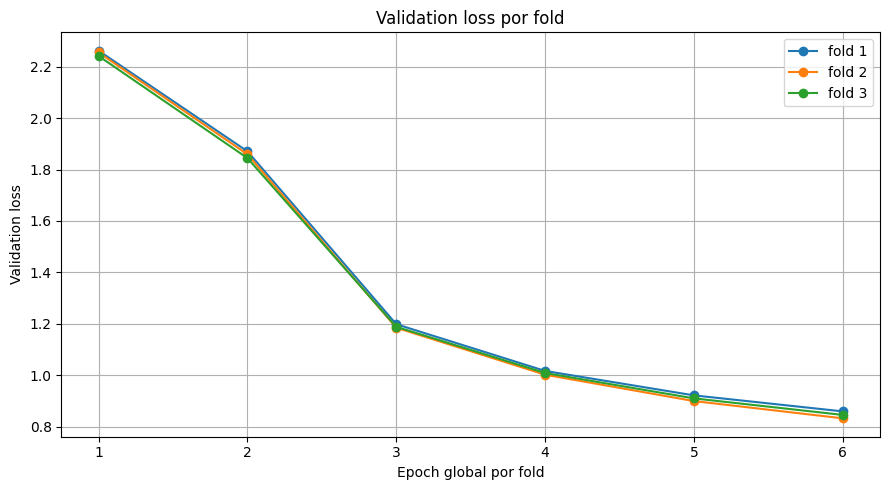

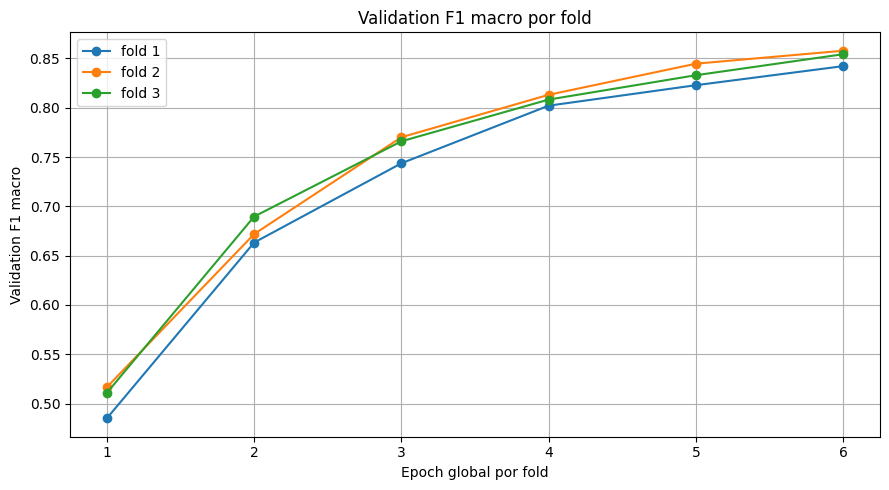

In [13]:
%matplotlib inline

plt.figure(figsize=(9, 5))
for fold in sorted(all_history_df["fold"].unique()):
    df_fold = all_history_df[all_history_df["fold"] == fold].reset_index(drop=True)
    plt.plot(df_fold.index + 1, df_fold["val_loss"], marker="o", label=f"fold {fold}")
plt.xlabel("Epoch global por fold")
plt.ylabel("Validation loss")
plt.title("Validation loss por fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
for fold in sorted(all_history_df["fold"].unique()):
    df_fold = all_history_df[all_history_df["fold"] == fold].reset_index(drop=True)
    plt.plot(df_fold.index + 1, df_fold["val_f1_macro"], marker="o", label=f"fold {fold}")
plt.xlabel("Epoch global por fold")
plt.ylabel("Validation F1 macro")
plt.title("Validation F1 macro por fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Cargar mejor checkpoint de CV

In [ ]:
best_row = cv_summary_df.sort_values("best_metric_value", ascending=False).iloc[0]
BEST_CV_MODEL_PATH = Path(best_row["best_model_path"])
print("Mejor fold:", int(best_row["fold"]))
print("Mejor checkpoint:", BEST_CV_MODEL_PATH)
print(f"{SELECTION_METRIC}:", best_row["best_metric_value"])


def load_trained_resnet50(checkpoint_path: Path, device: torch.device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = build_resnet50(num_classes=checkpoint["num_classes"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint


best_model, best_checkpoint = load_trained_resnet50(BEST_CV_MODEL_PATH, DEVICE)
idx_to_class_name = {int(k): v for k, v in best_checkpoint["idx_to_class_name"].items()}
print("Modelo cargado correctamente.")
print("idx_to_class_name:", idx_to_class_name)

DESTINATION_BEST_MODEL_PATH = Path(
    "/content/drive/MyDrive/ECHO/Model/resnet50_species_crop_padding20_cv_best.pt"
)
DESTINATION_BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(BEST_CV_MODEL_PATH, DESTINATION_BEST_MODEL_PATH)
print("Modelo copiado a:", DESTINATION_BEST_MODEL_PATH)

Mejor fold: 2
Mejor checkpoint: /content/saviia_species_training_crop_padding20_cv/outputs_crop_padding20_cv/fold_2/resnet50_crop_padding20_fold_2_best.pt
val_f1_macro: 0.8578085521039314
Modelo cargado correctamente.
idx_to_class_name: {0: 'Hued hued', 1: 'Pudu', 2: 'Liebre europea', 3: 'Oveja', 4: 'Perro domestico', 5: 'Vaca', 6: 'Zorro culpeo', 7: 'Vison americano', 8: 'Quique', 9: 'Jabali', 10: 'Zorro chilla', 11: 'Conejo europeo', 12: 'Puma', 13: 'Gato domestico', 14: 'Guina', 15: 'Chucao', 16: 'Zorzal', 17: 'Caballo', 18: 'Chingue', 19: 'Guanaco', 20: 'Huemul'}
Modelo copiado a: /content/drive/MyDrive/ECHO/Model/resnet50_species_crop_padding20_cv_best.pt


# Evaluación externa — detector + crop padding 20%

## 11. Setup evaluación

In [ ]:
EVAL_IMAGES_ZIP = Path(
    "/content/drive/MyDrive/ECHO/Metadata/downloaded_eval_images.zip"
)
EVAL_IMAGES_DIR = Path("/content/eval_downloaded_images_crop_padding20")
EVAL_TEMPLATE_PATH = Path(
    "/content/drive/MyDrive/ECHO/Metadata/Dataset_Evaluacion_EPII.xlsx"
)
EVAL_OUTPUT_PATH = Path(
    "/content/drive/MyDrive/ECHO/Metadata/Plantilla_Evaluacion_Rellenada_crop_padding20_cv.xlsx"
)
EVAL_OUTPUT_CSV = Path(
    "/content/drive/MyDrive/ECHO/Metadata/predicciones_evaluacion_crop_padding20_cv.csv"
)
SHEET_NAME = "Plantilla de Evaluación"

DET_CONF_THRESHOLD = 0.20
PADDING_RATIO = CROP_PADDING_RATIO

EVAL_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
if EVAL_IMAGES_ZIP.exists():
    with zipfile.ZipFile(EVAL_IMAGES_ZIP, "r") as zf:
        zf.extractall(EVAL_IMAGES_DIR)
    print("ZIP extraído en:", EVAL_IMAGES_DIR)
else:
    print("No se encontró ZIP. Se usará carpeta:", EVAL_IMAGES_DIR)

ZIP extraído en: /content/eval_downloaded_images_crop_padding20


## 12. Cargar detector y funciones de evaluación

In [ ]:
from PytorchWildlife.models import detection as pw_detection

DET_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
detector = pw_detection.MegaDetectorV6(device=DET_DEVICE, version="MDV6-yolov10-e")
print("Detector cargado en:", DET_DEVICE)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)


def detect_and_crop(img_path):
    with torch.inference_mode():
        result = detector.single_image_detection(str(img_path))

    detections = result["detections"].xyxy
    confidences = result["detections"].confidence
    if hasattr(detections, "cpu"):
        detections = detections.cpu().numpy().tolist()
    if hasattr(confidences, "cpu"):
        confidences = confidences.cpu().numpy().tolist()

    best_bbox, best_conf = get_best_detection(detections, confidences)
    if best_bbox is None or best_conf is None or best_conf < DET_CONF_THRESHOLD:
        return None, best_conf, None

    with Image.open(img_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")
        img_width, img_height = img.size
        bbox = prepare_bbox(
            best_bbox, img_width, img_height, padding_ratio=PADDING_RATIO
        )
        if bbox is None:
            return None, best_conf, None
        crop = img.crop(bbox)
    return crop, best_conf, bbox


def normalize_text(text):
    text = "" if text is None else str(text)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text.lower().strip()


EVAL_SPECIES_MAP = {
    "guina": "Gato huiña",
    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "puma": "Puma",
    "zorzal": "Zorzal patagonico",
    "zorzal patagonico": "Zorzal patagonico",
    "chucao": "Chucao",
    "pudu": "Pudu",
    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",
}


def to_eval_species(model_class_name):
    return EVAL_SPECIES_MAP.get(normalize_text(model_class_name), "Otro")


@torch.inference_mode()
def classify_crop(crop_img):
    x = eval_transform(crop_img).unsqueeze(0).to(DEVICE)
    logits = best_model(x)
    probs = torch.softmax(logits, dim=1)[0]
    pred_idx = int(torch.argmax(probs).item())
    pred_conf = float(probs[pred_idx].item())
    model_class_name = idx_to_class_name[pred_idx]
    eval_species = to_eval_species(model_class_name)
    return model_class_name, eval_species, pred_conf


def extract_excel_row_from_filename(img_path):
    match = re.search(r"row_(\d+)", img_path.stem)
    if not match:
        return None
    return int(match.group(1))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10x summary (fused): 191 layers, 29,399,417 parameters, 0 gradients, 160.0 GFLOPs
Detector cargado en: cuda


## 13. Generar predicciones en test externo

In [ ]:
if not EVAL_TEMPLATE_PATH.exists():
    candidates = list(
        Path(
            "/content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge"
        ).glob("Dataset_Evaluacion_EPII*.xlsx")
    )
    candidates += list(Path("/content").glob("Dataset_Evaluacion_EPII*.xlsx"))
    if len(candidates) == 0:
        raise FileNotFoundError("No se encontró el Excel de evaluación.")
    EVAL_TEMPLATE_PATH = candidates[0]

print("Usando plantilla:", EVAL_TEMPLATE_PATH)
wb = openpyxl.load_workbook(EVAL_TEMPLATE_PATH)
ws = wb[SHEET_NAME]
headers = {ws.cell(row=1, column=col).value: col for col in range(1, ws.max_column + 1)}
detect_col = headers["¿Detectas un animal claro?"]
species_col = headers["Especie (Clasificación)"]

valid_exts = {".jpg", ".jpeg", ".png", ".webp"}
image_paths = sorted(
    [p for p in EVAL_IMAGES_DIR.rglob("*") if p.suffix.lower() in valid_exts]
)
print("Imágenes encontradas:", len(image_paths))

results = []
for img_path in tqdm(image_paths, desc="Evaluando imágenes con crop padding 20%"):
    excel_row = extract_excel_row_from_filename(img_path)
    if excel_row is None:
        continue

    crop_img, det_conf, bbox = detect_and_crop(img_path)
    if crop_img is None:
        animal_clear = "No"
        eval_species = "Otro"
        model_class_name = None
        cls_conf = None
    else:
        animal_clear = "Si"
        model_class_name, eval_species, cls_conf = classify_crop(crop_img)

    ws.cell(row=excel_row, column=detect_col).value = animal_clear
    ws.cell(row=excel_row, column=species_col).value = eval_species

    results.append(
        {
            "excel_row": excel_row,
            "image_path": str(img_path),
            "detecta_animal_claro": animal_clear,
            "especie_evaluacion": eval_species,
            "clase_modelo_original": model_class_name,
            "det_conf": det_conf,
            "cls_conf": cls_conf,
            "bbox": bbox,
            "padding_ratio": PADDING_RATIO,
            "best_cv_model_path": str(BEST_CV_MODEL_PATH),
        }
    )

wb.save(EVAL_OUTPUT_PATH)
results_df = pd.DataFrame(results).sort_values("excel_row")
results_df.to_csv(EVAL_OUTPUT_CSV, index=False)

print("Excel rellenado:", EVAL_OUTPUT_PATH)
print("CSV predicciones:", EVAL_OUTPUT_CSV)
display(results_df.head(20))
print(results_df["detecta_animal_claro"].value_counts(dropna=False))
print(results_df["especie_evaluacion"].value_counts(dropna=False))

Usando plantilla: /content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge/Dataset_Evaluacion_EPII.xlsx
Imágenes encontradas: 77


Evaluando imágenes con crop padding 20%:   0%|          | 0/77 [00:00<?, ?it/s]


0: 1280x1280 1 animal, 227.0ms
Speed: 49.4ms preprocess, 227.0ms inference, 1.0ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 233.6ms
Speed: 14.0ms preprocess, 233.6ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 2 animals, 229.3ms
Speed: 13.6ms preprocess, 229.3ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 226.9ms
Speed: 10.3ms preprocess, 226.9ms inference, 0.5ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 225.5ms
Speed: 5.4ms preprocess, 225.5ms inference, 3.3ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 223.0ms
Speed: 5.9ms preprocess, 223.0ms inference, 0.5ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 224.8ms
Speed: 15.5ms preprocess, 224.8ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 221.8ms
Speed: 5.4ms preprocess, 221.8ms infer

,excel_row,image_path,detecta_animal_claro,especie_evaluacion,clase_modelo_original,det_conf,cls_conf,bbox,padding_ratio,best_cv_model_path
0,2,/content/eval_downloaded_images_crop_padding20...,Si,Gato huiña,Guina,0.883339,0.164585,"(1639, 1611, 3154, 2448)",0.2,/content/saviia_species_training_crop_padding2...
1,3,/content/eval_downloaded_images_crop_padding20...,Si,Zorzal patagonico,Zorzal,0.854140,0.403083,"(656, 1115, 922, 1473)",0.2,/content/saviia_species_training_crop_padding2...
2,4,/content/eval_downloaded_images_crop_padding20...,Si,Otro,Liebre europea,0.752975,0.329312,"(2331, 1408, 3264, 2448)",0.2,/content/saviia_species_training_crop_padding2...
3,5,/content/eval_downloaded_images_crop_padding20...,Si,Gato huiña,Guina,0.951253,0.359520,"(0, 874, 1748, 1440)",0.2,/content/saviia_species_training_crop_padding2...
4,6,/content/eval_downloaded_images_crop_padding20...,Si,Hued hued del sur,Hued hued,0.897499,0.242854,"(686, 433, 859, 683)",0.2,/content/saviia_species_training_crop_padding2...
5,7,/content/eval_downloaded_images_crop_padding20...,Si,Zorzal patagonico,Zorzal,0.803550,0.650914,"(785, 492, 1047, 697)",0.2,/content/saviia_species_training_crop_padding2...
6,8,/content/eval_downloaded_images_crop_padding20...,Si,Hued hued del sur,Hued hued,0.929259,0.521795,"(368, 872, 784, 1164)",0.2,/content/saviia_species_training_crop_padding2...
7,9,/content/eval_downloaded_images_crop_padding20...,Si,Chucao,Chucao,0.897501,0.468035,"(603, 479, 856, 701)",0.2,/content/saviia_species_training_crop_padding2...
8,10,/content/eval_downloaded_images_crop_padding20...,Si,Hued hued del sur,Hued hued,0.887220,0.479441,"(2749, 1469, 3151, 1819)",0.2,/content/saviia_species_training_crop_padding2...
9,11,/content/eval_downloaded_images_crop_padding20...,Si,Hued hued del sur,Hued hued,0.479239,0.331636,"(1718, 1735, 2009, 1996)",0.2,/content/saviia_species_training_crop_padding2...


detecta_animal_claro
Si    76
No     1
Name: count, dtype: int64
especie_evaluacion
Zorzal patagonico    17
Pudu                 16
Otro                 14
Hued hued del sur    12
Gato huiña            7
Puma                  6
Chucao                5
Name: count, dtype: int64


## 14. Métricas de evaluación externa

In [ ]:
GT_EXCEL_PATH = EVAL_TEMPLATE_PATH
GT_SHEET_NAME = "Ground Truth Dataset"

SPECIES_CANONICAL_MAP = {
    "chucao": "Chucao",
    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "guina": "Gato huiña",
    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",
    "pudu": "Pudú",
    "pudú": "Pudú",
    "puma": "Puma",
    "zorzal": "Zorzal patagónico",
    "zorzal patagonico": "Zorzal patagónico",
    "zorzal patagónico": "Zorzal patagónico",
    "unknown": "Unknown",
    "otro": "Unknown",
}


def norm_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    return x.lower().strip()


def canonical_species(x):
    key = norm_text(x)
    if key == "":
        return None
    return SPECIES_CANONICAL_MAP.get(key, "Unknown")


def is_detected(x):
    return norm_text(x) in {"si", "sí", "yes", "true", "1"}


def build_combined_pred(row):
    if not row["pred_detected"]:
        return "No detectado"
    if row["pred_species"] is None:
        return "Sin respuesta"
    return row["pred_species"]


gt_df = pd.read_excel(GT_EXCEL_PATH, sheet_name=GT_SHEET_NAME)
gt_df["excel_row"] = gt_df.index + 2
gt_df["gt_label"] = gt_df["Common Name"].apply(canonical_species)

pred_df = results_df.copy()
pred_df["pred_detected"] = pred_df["detecta_animal_claro"].apply(is_detected)
pred_df["pred_species"] = pred_df["especie_evaluacion"].apply(canonical_species)
pred_df["pred_combined_label"] = pred_df.apply(build_combined_pred, axis=1)

eval_df = gt_df.merge(pred_df, on="excel_row", how="inner")
eval_df["gt_combined_label"] = eval_df["gt_label"]
print("Filas evaluadas:", len(eval_df))

y_true = eval_df["gt_combined_label"]
y_pred = eval_df["pred_combined_label"]

overall_accuracy = accuracy_score(y_true, y_pred)
detection_score = eval_df["pred_detected"].mean()
cls_eval_df = eval_df[
    (eval_df["pred_detected"] == True) & (eval_df["pred_species"].notna())
].copy()
pure_classification_accuracy = (
    accuracy_score(cls_eval_df["gt_label"], cls_eval_df["pred_species"])
    if len(cls_eval_df) > 0
    else np.nan
)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
cohen_kappa = cohen_kappa_score(y_true, y_pred)

metrics_df = pd.DataFrame(
    [
        {
            "n": len(eval_df),
            "Accuracy": overall_accuracy,
            "Deteccion": detection_score,
            "Acc_clasificacion_pura": pure_classification_accuracy,
            "F1_macro": f1_macro,
            "F1_micro": f1_micro,
            "F1_weighted": f1_weighted,
            "padding_ratio": PADDING_RATIO,
            "best_cv_model_path": str(BEST_CV_MODEL_PATH),
        }
    ]
)

display(metrics_df)

report_df = pd.DataFrame(
    classification_report(y_true, y_pred, output_dict=True, zero_division=0)
).T
display(report_df)

Filas evaluadas: 77


,n,Accuracy,Deteccion,Acc_clasificacion_pura,F1_macro,F1_micro,F1_weighted,padding_ratio,best_cv_model_path
0,77,0.545455,0.987013,0.552632,0.471088,0.545455,0.538386,0.2,/content/saviia_species_training_crop_padding2...


,precision,recall,f1-score,support
Chucao,0.800000,0.363636,0.500000,11.000000
Gato huiña,0.571429,0.363636,0.444444,11.000000
Hued hued del sur,0.500000,0.545455,0.521739,11.000000
No detectado,0.000000,0.000000,0.000000,0.000000
Pudú,0.562500,0.818182,0.666667,11.000000
Puma,0.833333,0.454545,0.588235,11.000000
Unknown,0.307692,0.363636,0.333333,11.000000
Zorzal patagónico,0.588235,0.909091,0.714286,11.000000
accuracy,0.545455,0.545455,0.545455,0.545455
macro avg,0.520399,0.477273,0.471088,77.000000


## 15. Matriz de confusión y guardado de resultados

In [ ]:
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    xlabel="Predicción",
    ylabel="Ground Truth",
    title="Matriz de confusión — crop padding 20% + CV",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
        )
plt.tight_layout()
plt.show()

MODEL_EVAL_DIR = Path("/content/drive/MyDrive/ECHO/Model_Evaluation")
MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)

METRICS_OUTPUT_PATH = MODEL_EVAL_DIR / "metricas_modelo_eval_crop_padding20_cv.csv"
REPORT_OUTPUT_PATH = MODEL_EVAL_DIR / "reporte_clases_modelo_eval_crop_padding20_cv.csv"
CONFUSION_OUTPUT_PATH = (
    MODEL_EVAL_DIR / "matriz_confusion_modelo_eval_crop_padding20_cv.csv"
)
EVAL_ROWS_OUTPUT_PATH = MODEL_EVAL_DIR / "eval_rows_modelo_crop_padding20_cv.csv"
CV_SUMMARY_DRIVE_PATH = MODEL_EVAL_DIR / "cv_summary_crop_padding20.csv"
CV_HISTORY_DRIVE_PATH = MODEL_EVAL_DIR / "cv_history_crop_padding20.csv"

metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
report_df.to_csv(REPORT_OUTPUT_PATH)
cm_df.to_csv(CONFUSION_OUTPUT_PATH)
eval_df.to_csv(EVAL_ROWS_OUTPUT_PATH, index=False)
cv_summary_df.to_csv(CV_SUMMARY_DRIVE_PATH, index=False)
all_history_df.to_csv(CV_HISTORY_DRIVE_PATH, index=False)

print("Métricas:", METRICS_OUTPUT_PATH)
print("Reporte por clase:", REPORT_OUTPUT_PATH)
print("Matriz confusión:", CONFUSION_OUTPUT_PATH)
print("Filas evaluación:", EVAL_ROWS_OUTPUT_PATH)
print("Resumen CV:", CV_SUMMARY_DRIVE_PATH)
print("Historial CV:", CV_HISTORY_DRIVE_PATH)

,Chucao,Gato huiña,Hued hued del sur,No detectado,Pudú,Puma,Unknown,Zorzal patagónico
Chucao,4,1,2,0,2,0,0,2
Gato huiña,0,4,0,0,0,1,6,0
Hued hued del sur,0,0,6,1,1,0,1,2
No detectado,0,0,0,0,0,0,0,0
Pudú,0,1,0,0,9,0,0,1
Puma,0,0,0,0,4,5,2,0
Unknown,0,1,4,0,0,0,4,2
Zorzal patagónico,1,0,0,0,0,0,0,10


Métricas: /content/drive/MyDrive/ECHO/Model_Evaluation/metricas_modelo_eval_crop_padding20_cv.csv
Reporte por clase: /content/drive/MyDrive/ECHO/Model_Evaluation/reporte_clases_modelo_eval_crop_padding20_cv.csv
Matriz confusión: /content/drive/MyDrive/ECHO/Model_Evaluation/matriz_confusion_modelo_eval_crop_padding20_cv.csv
Filas evaluación: /content/drive/MyDrive/ECHO/Model_Evaluation/eval_rows_modelo_crop_padding20_cv.csv
Resumen CV: /content/drive/MyDrive/ECHO/Model_Evaluation/cv_summary_crop_padding20.csv
Historial CV: /content/drive/MyDrive/ECHO/Model_Evaluation/cv_history_crop_padding20.csv
